# Lecture 05 — Data Preprocessing, EDA & Feature Engineering
### Implementation Notebook

Welcome back! You can already describe data statistically and visualize it. Today answers the
next real question: **a dataset is almost never ready to analyze, let alone feed to a model —
how do I get it there, and how do I justify every decision I make along the way?**

**The business problem behind today, stated plainly:** you've just been handed a raw export —
maybe from HR, maybe from a partner system — full of the ordinary damage real data accumulates:
missing values, duplicated rows, wrong types, inconsistent spellings, impossible values, and
genuine outliers. Before you can trust a single chart or number from it, you have to *earn* that
trust through a deliberate process. That process is today's notebook.

**Notebook objectives** — by the end of today you'll be able to:
- Systematically assess a new dataset's quality before trusting anything in it
- Clean missing values, duplicates, wrong types, inconsistent categories, and invalid values —
  and explain *why* you chose each specific fix
- Detect and decide what to do with outliers (remove, keep, or cap)
- Encode categorical features and scale numerical features for machine learning
- Perform full univariate, bivariate, and correlation-based EDA — and extract real insight from it
- Engineer new features from raw columns
- Run this entire workflow independently, end to end, on the real Titanic dataset

**Today's workflow, which every major section follows:**

```
Business Problem → Think Before Coding → Live Coding → Checkpoint → Your Turn → Challenge → Discussion → Best Practices
```

Notice **"Think Before Coding"** comes before any code in every section. That's deliberate — the
goal today is decision-making, not memorizing function names. Anyone can look up `.fillna()`;
the skill is knowing *when* and *why*.

**No review of Python, NumPy, Pandas, Statistics, or Visualization today** — we're assuming all
of that is solid, and applying it immediately to real problems.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import (
    LabelEncoder, OrdinalEncoder, OneHotEncoder,
    MinMaxScaler, StandardScaler, RobustScaler,
)

%matplotlib inline
sns.set_theme(style="whitegrid")
titanic = pd.read_csv("../Session-03/titanic (1).csv")
print("numpy version  :", np.__version__)
print("pandas version :", pd.__version__)
print("sklearn ready")
print("Ready to go!")

numpy version  : 2.5.1
pandas version : 3.0.3
sklearn ready
Ready to go!


### Loading today's two datasets

**Employees (raw)** — our small teaching dataset, loaded **exactly as it might arrive from a
messy HR export**: inconsistent department names, a stray duplicate row, salary stored as text
with currency symbols, an impossible age, an unformatted join date, and a couple of missing
performance scores. Nothing here has been cleaned yet — that's the point.

**Titanic** — the real dataset (891 passengers) we'll apply every concept to for the rest of the
notebook.

In [6]:
employees_raw = pd.DataFrame({
    "EmployeeID": [101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 102],
    "Name": ["Sara", "Omar", "Lina", "Mostafa", "Nourhan", "Khaled", "Rana",
             "Ahmed", "Salma", "Yara", "Tarek", "Hossam", "Omar"],
    "Department": ["IT", "Sales", " IT", "HR", "Marketing", "sales", "IT",
                    "HR", "Marketing", "IT", "Sales", "IT", "Sales"],
    "Salary": ["$9,000", "$7,000", "$8,500", "$6,200", "$7,800", "$7,200", "$9,500",
               "$6,000", "$8,100", "$9,200", "-$500", "$32,000", "$7,000"],
    "Age": [29, 34, 27, 31, 26, 24, 33, -5, 28, 200, 30, 45, 34],
    "JoinDate": ["2019-03-15", "2021-07-01", "2020-01-10", "2018-11-23", "2022-05-05",
                 "2023-02-14", "09/09/2017", "2020-06-18", "2021-12-01", "2019-08-08",
                 "2022-03-19", "2010-04-01", "2021-07-01"],
    "PerformanceScore": [88, 75, np.nan, 80, 90, 65, 95, np.nan, 82, 84, 77, 97, 75],
    "City": ["Cairo", "Alexandria", "Cairo", "Giza", " Cairo", "Alexandria",
             "ALEXANDRIA", "Giza", "Cairo", "Cairo", "Alexandria", "Cairo", "Alexandria"],
})
employees_raw

,EmployeeID,Name,Department,Salary,Age,JoinDate,PerformanceScore,City
0,101,Sara,IT,"$9,000",29,2019-03-15,88.0,Cairo
1,102,Omar,Sales,"$7,000",34,2021-07-01,75.0,Alexandria
2,103,Lina,IT,"$8,500",27,2020-01-10,NaN,Cairo
3,104,Mostafa,HR,"$6,200",31,2018-11-23,80.0,Giza
4,105,Nourhan,Marketing,"$7,800",26,2022-05-05,90.0,Cairo
5,106,Khaled,sales,"$7,200",24,2023-02-14,65.0,Alexandria
6,107,Rana,IT,"$9,500",33,09/09/2017,95.0,ALEXANDRIA
7,108,Ahmed,HR,"$6,000",-5,2020-06-18,NaN,Giza
8,109,Salma,Marketing,"$8,100",28,2021-12-01,82.0,Cairo
9,110,Yara,IT,"$9,200",200,2019-08-08,84.0,Cairo


In [7]:
titanic = pd.read_csv("data/titanic.csv")
titanic.head()

FileNotFoundError: [Errno 2] No such file or directory: 'data/titanic.csv'

### 💬 Discussion — before we touch a single cell of code
Skim the `employees_raw` table above with your eyes only. Without running any code, list at
least 3 things that look "off" to you. Keep this list — we're about to build the exact same list
systematically in Section 2.

---
## 2. Data Quality Assessment

**Business problem:** *before we fix anything, we need a complete, honest picture of what's
actually wrong.* Fixing issues you haven't fully catalogued means you'll miss some — and possibly
"fix" something that wasn't actually broken.

**Think before coding:** what would you personally check first on a dataset you'd never seen
before — and why that, first?

### Initial inspection & dataset overview

Same tools from Lecture 03, applied here with a specific purpose: not just getting familiar with
the data, but building a checklist of problems to fix.

In [ ]:
print("Shape:", employees_raw.shape)
employees_raw.info()

In [ ]:
employees_raw.describe(include="all")

### Missing value detection

In [ ]:
employees_raw.isnull().sum()

### Duplicate detection

In [ ]:
print("Full-row duplicates:", employees_raw.duplicated().sum())
employees_raw[employees_raw.duplicated()]

### Incorrect data types

`.info()` above already hinted at this — look again at `Salary` and `JoinDate`. What `dtype`
would you *expect* each of those to be, and what are they actually?

In [ ]:
print("Salary dtype  :", employees_raw["Salary"].dtype, "-- expected: numeric")
print("JoinDate dtype:", employees_raw["JoinDate"].dtype, "-- expected: datetime")
print()
print("Sample Salary values:", employees_raw["Salary"].head(3).tolist())
print("Sample JoinDate values:", employees_raw["JoinDate"].head(3).tolist())

### Invalid values — impossible, regardless of type

A value can have the *correct type* and still be **impossible**. `Age` is numeric, as expected —
but is every number in it a plausible human age?

In [ ]:
print("Age summary:")
print(employees_raw["Age"].describe())
print()
suspicious_ages = employees_raw[(employees_raw["Age"] < 0) | (employees_raw["Age"] > 100)]
suspicious_ages[["Name", "Age"]]

### Inconsistent values — same real-world thing, different spellings

`Department` and `City` are the right *type* (text) and every individual value looks
individually plausible — the problem only appears when you look at the **set of unique values**.

In [ ]:
print("Unique Department values:", employees_raw["Department"].unique())
print("Unique City values      :", employees_raw["City"].unique())

`" IT"` and `"IT"` look identical to a human skimming the table, but they are **different
strings** to Pandas — any `groupby("Department")` or filter right now would silently split IT
into multiple groups. Same story with `"sales"` vs `"Sales"`, and `"Cairo"` vs `" Cairo"` vs
`"ALEXANDRIA"`.

### Outlier detection — a first look

We'll implement the full IQR/Z-score methods in Section 3.5 — for now, just a quick visual
gut-check.

In [ ]:
plt.figure(figsize=(7, 3))
sns.boxplot(x=employees_raw["Age"])
plt.title("Age -- something is very wrong here")
plt.show()

### 🏋️ Student Practice
Run the same quality-assessment checklist on `titanic`:
1. `.info()` and `.describe(include="all")`.
2. Missing value counts per column.
3. Duplicate row count.
4. Any column whose `dtype` looks wrong for what it represents?
5. Any suspicious/impossible values you can spot in `Age` or `Fare`?

In [ ]:
# Your code here





### ✅ Checkpoint — our quality assessment findings on `employees_raw`
- **Missing values**: `PerformanceScore` — 2 missing.
- **Duplicates**: 1 full-row duplicate (`Omar`, `EmployeeID 102`).
- **Incorrect types**: `Salary` is text (currency-formatted), not numeric. `JoinDate` is text,
  not a real date — and one row (`Rana`) even uses a *different* date format than the rest.
- **Invalid values**: `Ahmed`'s `Age` is `-5` (impossible). `Yara`'s `Age` is `200` (impossible).
  `Tarek`'s `Salary` is negative (impossible).
- **Inconsistent values**: `Department` has `"IT"` / `" IT"` / and casing issues on `"sales"`.
  `City` has leading-space and all-caps variants of the same three real cities.
- **Outliers**: `Hossam`'s salary (32000) is far above everyone else's — but unlike the invalid
  values above, this one is *plausible* (a senior employee), which is exactly why outliers and
  invalid values need to be told apart, and why we'll treat them as separate problems in
  Section 3.

This list **is** our cleaning plan for Section 3 — every one of these gets fixed, in roughly this
order.

---
## 3. Data Cleaning

**Business problem:** *we now have a full list of problems. Fixing each one wrong (or in the
wrong order) can quietly bias every result downstream.* This section works through each problem
type from our checklist, one at a time, with the reasoning behind each fix made explicit.

We'll clean `employees_raw` step by step into a working copy, `employees`, so you can always
compare back to the original.

In [ ]:
employees = employees_raw.copy()

### 3.1 Missing Values

**Think before coding:** a missing value can mean very different things — "not applicable,"
"not yet recorded," "lost in a system migration." The *right* fix depends on which of those is
true, not on a fixed rule.

#### Detect and calculate missing percentages

In [ ]:
missing_count = employees.isnull().sum()
missing_percent = (employees.isnull().sum() / len(employees) * 100).round(1)

missing_summary = pd.DataFrame({"missing_count": missing_count, "missing_percent": missing_percent})
missing_summary[missing_summary["missing_count"] > 0]

#### Visualize missing values

A quick visual makes missingness patterns easier to spot than scanning numbers, especially on
wider tables.

In [ ]:
plt.figure(figsize=(6, 3))
sns.barplot(x=missing_summary.index, y=missing_summary["missing_percent"], color="indianred")
plt.title("Missing Value Percentage per Column")
plt.ylabel("% missing")
plt.xticks(rotation=30)
plt.show()

#### Strategy 1 — Drop rows

Use when: very few rows are affected, and each carries multiple problems anyway (not the case
here, but let's see the mechanics).

In [ ]:
employees_drop_rows = employees.dropna(subset=["PerformanceScore"])
print("Before:", employees.shape, "-> After dropping rows:", employees_drop_rows.shape)

#### Strategy 2 — Drop columns

Use when: a column is missing so much of its data that it's no longer trustworthy or useful
(recall `Cabin` in Titanic — over 77% missing is a strong case for this, or at minimum for the
"convert to a boolean presence flag" approach we used in the Lecture 03 solution).

In [ ]:
employees_drop_col_demo = employees.drop(columns=["PerformanceScore"])
print("Columns after dropping:", employees_drop_col_demo.columns.tolist())
print("(We're NOT actually doing this to our real `employees` -- 2 missing out of 13 rows doesn't justify losing the whole column.)")

#### Strategy 3 — Fill with mean / median / mode

In [ ]:
mean_fill = employees["PerformanceScore"].fillna(employees["PerformanceScore"].mean())
median_fill = employees["PerformanceScore"].fillna(employees["PerformanceScore"].median())
mode_fill = employees["PerformanceScore"].fillna(employees["PerformanceScore"].mode()[0])

comparison = pd.DataFrame({
    "original": employees["PerformanceScore"],
    "mean_fill": mean_fill.round(1),
    "median_fill": median_fill,
    "mode_fill": mode_fill,
})
comparison[employees["PerformanceScore"].isnull()]

#### Strategy 4 — Fill with a constant value

Use when: missing genuinely means a specific known state, not "unknown" — e.g. a `Bonus` column
where missing really means "no bonus," i.e. `0`, not an average bonus.

In [ ]:
constant_fill = employees["PerformanceScore"].fillna(0)
constant_fill[employees["PerformanceScore"].isnull()]

#### Strategy 5 — Forward fill and backward fill

**Forward fill** (`ffill`) carries the last known value forward; **backward fill** (`bfill`)
carries the next known value backward. These only make sense when row **order carries meaning**
— typically time series or sequential logs — which `employees` doesn't really have. Let's use a
clean, standalone example instead.

In [ ]:
daily_temperatures = pd.Series([22.0, np.nan, np.nan, 25.0, 26.0, np.nan, 24.0],
                                index=pd.date_range("2024-01-01", periods=7))
print("Original:")
print(daily_temperatures)

print("\nForward fill (carries the last known reading forward):")
print(daily_temperatures.ffill())

print("\nBackward fill (carries the next known reading backward):")
print(daily_temperatures.bfill())

Notice `ffill` and `bfill` disagree wherever there's a gap — which one is "right" depends
entirely on what you're modeling (does yesterday's temperature carry forward better than
tomorrow's carries backward? Usually yes, which is why `ffill` is the far more common default for
real time series).

#### Our actual decision for `employees`

`PerformanceScore` is numeric, only 2 of 13 rows are missing, and there's no natural order to
exploit with `ffill`/`bfill` here — a **median fill** is a reasonable, defensible default (more
robust to `Hossam`'s high score than a mean fill would be).

In [ ]:
employees["PerformanceScore"] = employees["PerformanceScore"].fillna(employees["PerformanceScore"].median())
employees[["Name", "PerformanceScore"]]

### 🏋️ Student Practice
1. Create a small `Series` with at least 2 missing values, and fill it 3 different ways (mean,
   median, a constant of your choice). Compare the results.
2. On `titanic`, decide and justify a fill strategy for `Age` (you did this in Lecture 03 — repeat
   it here to warm back up).

### 🔥 Challenge Question
`Cabin` in `titanic` is over 77% missing. Make the case for **each** of these three approaches:
drop the column entirely, fill it with a placeholder like `"Unknown"`, or convert it into a
boolean `HasCabin` flag. Which would you actually choose, and why?

In [ ]:
# Your code / answers here





### ✅ Checkpoint — Missing Values
- No single fix is universally "correct" — the right strategy depends on how much is missing,
  what missingness *means* for that specific column, and what you'll do with the column
  afterward. `ffill`/`bfill` only make sense when row order is meaningful.

### 3.2 Duplicate Data

**Think before coding:** with a real unique ID (`EmployeeID`), what would a duplicate row even
mean here, versus how you'd interpret one on a dataset *without* an ID?

In [ ]:
print("Full-row duplicates:", employees.duplicated().sum())
print("Duplicate EmployeeIDs :", employees['EmployeeID'].duplicated().sum())
employees[employees.duplicated()]

In [ ]:
employees = employees.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", employees.shape)

### 🏋️ Student Practice
Confirm `titanic.duplicated().sum()` is `0` (you established this in Lecture 03) — then explain,
in one sentence, why a nonzero result here would be a stronger red flag than it would be on a
dataset without `PassengerId`.

In [ ]:
# Your code here




### ✅ Checkpoint — Duplicates
- Always check duplicates **before** other cleaning steps that might accidentally create new
  ones (e.g. dropping an ID column). With a genuine unique key, a duplicate is a real
  data-quality signal, not just a coincidence.

### 3.3 Incorrect Data Types

**Think before coding:** `Salary` currently looks like a number to a human, but Pandas sees text.
What operations would silently fail, or silently give the wrong answer, if we tried to compute
with it as-is?

In [ ]:
try:
    employees["Salary"].mean()
except TypeError as e:
    print("Error:", e)

#### Convert numeric columns

Strip the currency symbol and thousands-separator, then convert to a real numeric type.

In [ ]:
employees["Salary"] = (
    employees["Salary"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)
employees[["Name", "Salary"]]

In [ ]:
print("Now Salary is numeric:", employees['Salary'].dtype)
print("Mean salary:", employees['Salary'].mean().round(2))

#### Convert dates

`JoinDate` is text, and — as we spotted in Section 2 — not even in one consistent format
(`Rana`'s row uses `MM/DD/YYYY` instead of `YYYY-MM-DD`). `format="mixed"` tells Pandas to infer
each value's format individually rather than assuming one format for the whole column.

In [ ]:
employees["JoinDate"] = pd.to_datetime(employees["JoinDate"], format="mixed")
employees[["Name", "JoinDate"]]

In [ ]:
print("JoinDate dtype:", employees['JoinDate'].dtype)
print("Earliest hire  :", employees['JoinDate'].min())
print("Most recent    :", employees['JoinDate'].max())

Now that it's a real datetime, we get date arithmetic for free — something completely
unavailable while it was text.

In [ ]:
employees["YearsAtCompany"] = (pd.Timestamp("today") - employees["JoinDate"]).dt.days / 365.25
employees["YearsAtCompany"] = employees["YearsAtCompany"].round(1)
employees[["Name", "JoinDate", "YearsAtCompany"]]

#### Convert categorical columns

`Department` and `City` are text with a small, fixed set of real-world values — a great fit for
Pandas' `category` dtype, which is more memory-efficient and signals intent clearly.

In [ ]:
employees["Department"] = employees["Department"].astype("category")
print(employees["Department"].dtype)
print(employees["Department"].cat.categories.tolist())

Notice this converted **every distinct string**, including our known inconsistencies
(`"IT"`, `" IT"`) into separate categories — converting to `category` dtype does *not* fix
inconsistent values. That's next.

### 🏋️ Student Practice
1. Convert `titanic["Pclass"]` to `category` dtype (recall from Lecture 04 — it's statistically
   ordinal, even though it's stored as a number).
2. On a copy of `titanic`, try converting `Sex` to `category` dtype and check `.cat.categories`.

### ✅ Checkpoint — Incorrect Data Types
- The wrong dtype doesn't just look untidy — it silently blocks real operations (`.mean()` on
  text) or silently gives a wrong-but-plausible answer. Always convert types **before**
  everything downstream that assumes them, and remember `category` dtype does not fix
  inconsistent spellings — it just formalizes whatever strings already exist.

In [ ]:
# Your code here





### 3.4 Inconsistent Data

**Think before coding:** `" IT"`, `"IT"`, and `"sales"`/`"Sales"` are each individually valid
department names — the problem is Pandas treating them as *different* categories. What would
break downstream if we left this alone (think back to Lecture 03's discussion of this exact
issue)?

#### Strip spaces and fix capitalization

In [ ]:
employees["Department"] = employees["Department"].astype(str).str.strip().str.title()
employees["City"] = employees["City"].astype(str).str.strip().str.title()

print("Department:", sorted(employees["Department"].unique()))
print("City      :", sorted(employees["City"].unique()))

`.str.strip()` removed the stray leading space; `.str.title()` normalized casing
(`"sales"` → `"Sales"`, `"ALEXANDRIA"` → `"Alexandria"`). Both are now clean, consistent
categories.

#### Replace inconsistent categories that `.str` methods can't fix alone

Sometimes the inconsistency isn't spacing or casing — it's genuinely different spellings or
abbreviations for the same thing (`"NY"` vs `"New York"`, `"F"` vs `"Female"`). `.replace()` with
a mapping dictionary handles that case directly.

In [ ]:
department_corrections = {
    "It": "IT",   # .title() turned "IT" into "It" -- fix that specific case explicitly
}
employees["Department"] = employees["Department"].replace(department_corrections)
sorted(employees["Department"].unique())

This is a good example of **why order matters** in cleaning: `.str.title()` was the right
general-purpose fix, but it introduced a *new*, smaller inconsistency (`"It"` instead of `"IT"`)
that needed one more targeted correction.

### 🏋️ Student Practice
1. Check `titanic["Embarked"].unique()` — are there any spacing/casing issues to fix? (There may
   genuinely be none — confirming a column is *already* clean is a legitimate, useful check.)
2. Suppose a `Sex` column had values `["male", "Male", "M", "female", "Female", "F"]`. Write the
   `.replace()` mapping dictionary you'd use to normalize all of these down to just `"male"` /
   `"female"`.

### ✅ Checkpoint — Inconsistent Data
- `.str.strip()` and `.str.title()`/`.str.lower()` fix spacing and casing generically.
  `.replace()` with an explicit mapping handles genuinely different spellings a generic method
  can't guess. Always re-check `.unique()` *after* cleaning — a generic fix can introduce a new,
  smaller inconsistency, as we just saw.

In [ ]:
# Your code here





### 3.5 Invalid Values

**Think before coding:** unlike inconsistent *spelling*, an invalid value is wrong regardless of
how it's written — `Age = 200` isn't a formatting issue, it's factually impossible. How would you
even detect this systematically, rather than by eyeballing a table?

In [ ]:
invalid_age_mask = (employees["Age"] < 0) | (employees["Age"] > 100)
employees[invalid_age_mask][["Name", "Age"]]

In [ ]:
invalid_salary_mask = employees["Salary"] < 0
employees[invalid_salary_mask][["Name", "Salary"]]

#### Correct or remove — a genuine judgment call

- `Ahmed`'s `Age = -5` — very likely a **sign error** during entry (should probably be `5`? or
  more likely, a placeholder for missing that someone encoded incorrectly). With no way to
  recover the true value confidently, treating it as **missing** and filling it is safer than
  guessing.
- `Yara`'s `Age = 200` — no plausible correction exists; treat as **missing** too.
- `Tarek`'s `Salary = -500` — a negative salary is never valid; likely a sign error on data
  entry, but again unrecoverable with confidence. Treat as **missing**, then fill.

In [ ]:
employees.loc[invalid_age_mask, "Age"] = np.nan
employees.loc[invalid_salary_mask, "Salary"] = np.nan

employees["Age"] = employees["Age"].fillna(employees["Age"].median())
employees["Salary"] = employees["Salary"].fillna(employees["Salary"].median())

employees[["Name", "Age", "Salary"]]

**Note the pattern:** invalid values got converted to missing, then handled with the exact
same fill strategies from Section 3.1 — invalid-value handling and missing-value handling are
closely related, not two unrelated skills.

### 🏋️ Student Practice
1. Define what counts as an "invalid" `Fare` in `titanic` (hint: can a fare legitimately be
   `0`? Under what real circumstance might that actually be true — think about who was aboard).
2. Check whether any `titanic["Fare"]` values are negative.

### ✅ Checkpoint — Invalid Values
- Invalid means "impossible regardless of spelling or type" — a value that passes every type and
  formatting check can still be nonsense. When you can't confidently correct an invalid value,
  converting it to missing and applying a defensible fill strategy is safer than guessing at a
  "corrected" number.

In [ ]:
# Your code here





### 3.6 Outliers

**Think before coding:** we already fixed `employees_raw`'s two *invalid* ages and one *invalid*
salary. `Hossam`'s salary is still in the data — is it invalid the same way? Or is this a
different kind of problem?

In [ ]:
def iqr_bounds(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

def z_scores(series):
    return (series - series.mean()) / series.std()

lower, upper = iqr_bounds(employees["Salary"])
z = z_scores(employees["Salary"])

print(f"IQR bounds: [{lower:.0f}, {upper:.0f}]")
print("IQR method flags   :", employees[(employees['Salary'] < lower) | (employees['Salary'] > upper)]['Name'].tolist())
print("Z-score (|z|>2) flags:", employees[z.abs() > 2]['Name'].tolist())

Both methods agree: `Hossam` is the one outlier. Unlike `Ahmed`'s `-5` age, `Hossam`'s salary
is **plausible** — a senior employee legitimately earning more. This is a genuinely different
decision than Section 3.5's.

#### Three options — remove, keep, or cap

- **Remove** — appropriate if this row would badly distort a specific downstream analysis (e.g.
  training a model where one extreme value dominates the loss) and the row itself isn't otherwise
  informative.
- **Keep** — appropriate if the outlier is real, legitimate, and the analysis needs to reflect
  reality, including its extremes (e.g. a report on total payroll cost — excluding `Hossam` would
  understate real spending).
- **Cap (winsorize)** — a middle ground: pull extreme values *in* to a defined boundary, rather
  than deleting the row entirely. Preserves the row (and its other column values) while limiting
  the outlier's influence on statistics like the mean.

In [ ]:
employees["Salary_capped"] = employees["Salary"].clip(lower=lower, upper=upper)
employees[["Name", "Salary", "Salary_capped"]].sort_values("Salary", ascending=False)

In [ ]:
print("Mean salary, original:", employees['Salary'].mean().round(0))
print("Mean salary, capped   :", employees['Salary_capped'].mean().round(0))

#### Before vs. After — visualizing the effect of capping

Comparing means (above) tells us *something* changed, but a picture makes the actual shift in the
distribution much clearer. Watch how the top of the histogram and the box plot's upper whisker /
outlier point change once `Hossam`'s salary is pulled in to the IQR boundary.

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

sns.histplot(employees["Salary"], kde=True, ax=axes[0, 0], color="indianred")
axes[0, 0].set_title("Salary -- Before (Histogram)")

sns.histplot(employees["Salary_capped"], kde=True, ax=axes[0, 1], color="seagreen")
axes[0, 1].set_title("Salary -- After Capping (Histogram)")

sns.boxplot(x=employees["Salary"], ax=axes[1, 0], color="indianred")
axes[1, 0].set_title("Salary -- Before (Box Plot)")

sns.boxplot(x=employees["Salary_capped"], ax=axes[1, 1], color="seagreen")
axes[1, 1].set_title("Salary -- After Capping (Box Plot)")

plt.tight_layout()
plt.show()

**Our decision for `employees`:** we'll **keep** `Salary` as-is going forward (not
`Salary_capped`) — for a small company payroll table, an accurate total matters more than a
"tidier" distribution, and one genuine senior salary shouldn't be treated as an error.

### 🏋️ Student Practice
1. Apply both the IQR method and the Z-score method to `titanic["Fare"]` (you did this in
   Lecture 04 — repeat it here as warm-up).
2. Create a `Fare_capped` column using `.clip()` with the IQR bounds, and compare the mean of
   `Fare` vs. `Fare_capped`.
3. Make the case for your own choice: for `Fare`, would you remove, keep, or cap the outliers,
   assuming the next step is training a machine learning model? Justify it in 1–2 sentences.

### ✅ Checkpoint — Outliers
- An outlier is not automatically an error — that's the key difference from Section 3.5's invalid
  values. Removing, keeping, and capping are three legitimate, different choices, and the right
  one depends entirely on what the cleaned data will be used for next.

In [ ]:
# Your code here





### Our fully cleaned `employees` table

In [ ]:
employees[["EmployeeID", "Name", "Department", "Salary", "Age", "JoinDate",
           "PerformanceScore", "City"]]

---
## 4. Preparing Features for Machine Learning

**Business problem:** *models need numbers, not labels — and numbers on wildly different scales
can quietly bias many algorithms toward whichever feature happens to have the biggest raw values.*
Encoding and scaling exist to fix exactly these two problems.

### 4.1 Encoding — turning categories into numbers

**Think before coding:** `Department` has no natural order; `Pclass` (from Titanic) does. Should
these two be encoded the same way? What might go wrong if they were?

#### Label Encoding

Assigns each category an arbitrary integer. Fast and simple — but **implies an order that might
not exist**, which is risky for nominal data.

In [ ]:
label_encoder = LabelEncoder()
employees["Department_label"] = label_encoder.fit_transform(employees["Department"])
employees[["Department", "Department_label"]].drop_duplicates().sort_values("Department_label")

Notice `IT`, `HR`, `Marketing`, and `Sales` got mapped to `0, 1, 2, 3` — alphabetically, with
**no relationship to anything meaningful**. A model using this column raw might quietly learn
"Sales > IT" as if that meant something, purely because `3 > 0`. That's the core risk of Label
Encoding on nominal data.

#### Ordinal Encoding

Same mechanic as Label Encoding, but **you** specify the category order — appropriate exactly
when a real order exists.

In [ ]:
pclass_order = [[1, 2, 3]]   # 1st class is "highest", so we list it first
ordinal_encoder = OrdinalEncoder(categories=pclass_order)

titanic["Pclass_ordinal"] = ordinal_encoder.fit_transform(titanic[["Pclass"]])
titanic[["Pclass", "Pclass_ordinal"]].drop_duplicates().sort_values("Pclass")

Here the encoded value (`0, 1, 2`) genuinely reflects the real-world order (1st, 2nd, 3rd
class) — this is the appropriate use case for ordinal encoding, unlike `Department` above.

#### One-Hot Encoding

Creates one new binary (0/1) column **per category**, with no implied order at all — the
standard, safest choice for nominal data.

In [ ]:
one_hot = pd.get_dummies(employees["Department"], prefix="Dept")
pd.concat([employees[["Name", "Department"]], one_hot], axis=1)

### 🔮 Predict the Output
Before running the next cell: if `Department` has 4 unique categories, how many new columns will
`pd.get_dummies(..., drop_first=True)` create instead of 4?

In [ ]:
one_hot_dropfirst = pd.get_dummies(employees["Department"], prefix="Dept", drop_first=True)
one_hot_dropfirst.head()

If you predicted **3**, that's right — `drop_first=True` removes one column, since it's
mathematically redundant (if `Dept_HR`, `Dept_Marketing`, and `Dept_Sales` are all `0`, the
row *must* be `IT` — no information is lost). This avoids a subtle problem called the "dummy
variable trap" in some models, at the cost of one category no longer having its own explicit
column.

#### Briefly: three more encoding strategies you'll encounter

- **Frequency Encoding** — replace each category with how often it appears in the data. Simple,
  and can actually carry useful signal (a rare category might behave differently than a common
  one) — but two *different* categories that happen to appear equally often become
  indistinguishable to the model.

In [ ]:
frequency_map = employees["Department"].value_counts(normalize=True)
employees["Department_freq"] = employees["Department"].map(frequency_map)
employees[["Department", "Department_freq"]].drop_duplicates()

- **Binary Encoding** — converts each category's Label-Encoded integer into binary digits,
  spread across a handful of columns (e.g. category `5` → `101`) — a middle ground between
  One-Hot's many columns and Label Encoding's single, order-implying one. Common in libraries like
  `category_encoders`, not something we'll implement by hand today.
- **Target Encoding** — replaces each category with the *average target value* for that category
  (e.g. average `Survived` rate per `Embarked` port). Powerful, but risks **leaking information
  from the target into your features** if not done carefully (typically requires cross-validation
  safeguards) — a topic for when we start building models.

### 🏋️ Student Practice
1. Label-encode `titanic["Sex"]`. Does the arbitrary `0`/`1` assignment risk implying a false
   order here, the way it did for `Department`? Why or why not (hint: how many categories does
   `Sex` have)?
2. One-hot encode `titanic["Embarked"]` with `pd.get_dummies()`.
3. Frequency-encode `titanic["Pclass"]` and compare it to the ordinal encoding from earlier —
   which one would you actually use for a real model, and why?

### 🔥 Challenge Question
`Cabin`'s first letter (`A`, `B`, `C`, ...) represents deck level — genuinely ordinal in a rough
sense (upper decks vs. lower). Given `Cabin` has ~148 unique raw values but only a handful of deck
letters, would you Label Encode, Ordinal Encode, or One-Hot Encode the *deck letter* (not the raw
cabin number)? Justify your choice.

In [ ]:
# Your code here





### ✅ Checkpoint — Encoding
- **Label Encoding**: arbitrary integers, risks implying false order — use cautiously, mostly for
  tree-based models that don't care about magnitude. **Ordinal Encoding**: same mechanic, but
  *you* define a real order — use when one genuinely exists. **One-Hot Encoding**: one column per
  category, no implied order — the safest general default for nominal data, at the cost of more
  columns. Frequency/Binary/Target encoding exist for when categories are numerous or you need
  something more compact.

#### Encoding Techniques at a Glance

| Technique | When to Use | Advantages | Limitations |
|---|---|---|---|
| **Label Encoding** | Categories with a rough order, or as raw input to tree-based models | Simple, single column, no extra memory | Implies false order if used on nominal data |
| **Ordinal Encoding** | Categories with a genuine, known real-world order (e.g. `Pclass`, education level) | Preserves meaningful rank for the model | Wrong choice if the "order" is arbitrary or debatable |
| **One-Hot Encoding** | Nominal categories, especially with few unique values | No implied order — safest general default | Many new columns with high-cardinality features (curse of dimensionality) |
| **Frequency Encoding** | Many categories, where how *common* a category is might carry signal | Compact, stays a single column | Two different categories with equal frequency become indistinguishable |
| **Binary Encoding** | High-cardinality nominal features where One-Hot would be too wide | Fewer columns than One-Hot, richer than Label | Less directly interpretable; needs an external library |
| **Target Encoding** | Advanced workflows, high-cardinality categorical features | Can capture strong predictive signal | Risk of target leakage — needs careful cross-validation |

### 4.2 Scaling — putting numerical features on comparable footing

**Think before coding:** `Age` ranges roughly 0–80; `Fare` ranges roughly 0–512. Some ML
algorithms (anything distance-based, like KNN, or gradient-based, like linear/logistic
regression) will let the larger-range feature dominate purely because of its scale — not because
it's actually more important. Scaling fixes that.

#### Min-Max Scaling — squeezes everything into `[0, 1]`

In [ ]:
minmax_scaler = MinMaxScaler()
employees["Salary_minmax"] = minmax_scaler.fit_transform(employees[["Salary"]])
employees[["Name", "Salary", "Salary_minmax"]].sort_values("Salary")

#### Standard Scaling — centers on mean `0`, standard deviation `1` (a Z-score, exactly like
Lecture 04's outlier detection formula)

In [ ]:
standard_scaler = StandardScaler()
employees["Salary_standard"] = standard_scaler.fit_transform(employees[["Salary"]])
employees[["Name", "Salary", "Salary_standard"]].sort_values("Salary")

#### Robust Scaling — uses the median and IQR instead of mean and std

Built specifically to resist outliers, the way median resisted `Hossam`'s salary back in
Lecture 04's central tendency discussion.

In [ ]:
robust_scaler = RobustScaler()
employees["Salary_robust"] = robust_scaler.fit_transform(employees[["Salary"]])
employees[["Name", "Salary", "Salary_robust"]].sort_values("Salary")

### Comparing all three, visually

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(employees["Salary_minmax"], ax=axes[0], color="steelblue", kde=True)
axes[0].set_title("Min-Max Scaled")

sns.histplot(employees["Salary_standard"], ax=axes[1], color="darkorange", kde=True)
axes[1].set_title("Standard Scaled")

sns.histplot(employees["Salary_robust"], ax=axes[2], color="seagreen", kde=True)
axes[2].set_title("Robust Scaled")

plt.tight_layout()
plt.show()

### 💬 Discussion
Look at where `Hossam`'s scaled value lands in each of the three charts above (the rightmost bar
in each). Which scaler visibly compresses the *rest* of the data the most, purely because of one
outlier — Min-Max, Standard, or Robust? Why does that happen mechanically, given each method's
formula?

### 🏋️ Student Practice
1. Apply all three scalers to `titanic["Fare"]`.
2. Given `Fare` is heavily right-skewed with real outliers (Lecture 04), which scaler would you
   actually pick for a real model, and why — tie your answer to what you just observed about
   `Salary` above.
3. Apply `StandardScaler` to `titanic["Age"]` and confirm the result has (approximately) mean `0`
   and standard deviation `1`.

In [ ]:
# Your code here





### ✅ Checkpoint — Scaling
- **Min-Max**: squeezes to `[0, 1]`, but is *very* sensitive to outliers (they define the range
  everything else gets squeezed into). **Standard**: centers on mean/std — better than Min-Max
  for outliers, but still uses the (outlier-sensitive) mean and std. **Robust**: uses
  median/IQR — the most resistant of the three, and usually the right default whenever you know a
  column has real outliers.

#### ⚠️ Common Scaling Mistakes

- **Fitting the scaler on the full dataset before the train/test split.** The scaler then "sees"
  the test set's mean/std/min/max, leaking information and giving an overly optimistic sense of
  model performance. Always `fit()` on the training data only, then `transform()` (not
  `fit_transform()`) the test set with those same fitted statistics.
- **Scaling the target variable** (e.g. `Survived`, or a regression target) **without a deliberate
  reason.** For a classification target this makes no sense at all; even for a regression target,
  scaling `y` is a separate, intentional decision — not something to do automatically alongside
  your features.
- **Scaling one-hot / dummy columns.** A 0/1 indicator is already on a comparable, bounded scale —
  scaling it just adds noise and makes the column harder to interpret.
- **Forgetting to reuse the *same* fitted scaler at prediction time.** The exact `mean_`/`std_` (or
  `min_`/`max_`) learned from training data must be reused later; fitting a brand-new scaler on
  new data silently changes what every scaled value means.
- **Scaling before handling missing values.** Most scalers can't handle `NaN`, and computing
  statistics like mean/std on data that still has gaps can distort the result.

---
## 5. Exploratory Data Analysis (EDA)

**Business problem:** *the data is clean and ML-ready — but before building anything, a good
analyst asks what the data is actually saying.* From here on, we work entirely with `titanic` —
clean, real, and rich enough to have genuine stories in it.

**Think before coding:** what do you predict drove survival on the Titanic, before looking at any
numbers? Write down 2 guesses — we'll check them against the data as we go.

### 5.1 Univariate Analysis — one variable at a time

#### Numerical columns

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(titanic["Age"].dropna(), kde=True, ax=axes[0], color="cornflowerblue")
axes[0].set_title("Age Distribution")

sns.histplot(titanic["Fare"], kde=True, ax=axes[1], color="salmon")
axes[1].set_title("Fare Distribution")

plt.tight_layout()
plt.show()

titanic[["Age", "Fare"]].describe()

#### Categorical columns

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.countplot(x="Survived", data=titanic, hue="Survived", ax=axes[0], palette="Set2", legend=False)
axes[0].set_title("Survived")

sns.countplot(x="Pclass", data=titanic, hue="Pclass", ax=axes[1], palette="Set2", legend=False)
axes[1].set_title("Pclass")

sns.countplot(x="Sex", data=titanic, hue="Sex", ax=axes[2], palette="Set2", legend=False)
axes[2].set_title("Sex")

plt.tight_layout()
plt.show()

### 💬 Discussion
From the univariate charts alone (before comparing anything to `Survived`): which single-column
observation surprises you most? For example, does the `Pclass` distribution match what you'd
picture for a ship's real passenger mix?

### 5.2 Bivariate Analysis — two variables together

#### Numerical vs. Numerical

In [ ]:
plt.figure(figsize=(6, 5))
sns.scatterplot(x="Age", y="Fare", data=titanic, alpha=0.4, color="teal")
plt.title("Age vs. Fare")
plt.show()

print("Correlation:", titanic["Age"].corr(titanic["Fare"]).round(3))

#### Numerical vs. Categorical

In [ ]:
plt.figure(figsize=(7, 4))
sns.boxplot(x="Survived", y="Fare", data=titanic, hue="Survived", palette="Set2", legend=False)
plt.title("Fare by Survival")
plt.show()

print(titanic.groupby("Survived")["Fare"].agg(["mean", "median"]).round(2))

#### Categorical vs. Categorical

In [ ]:
survival_by_class_sex = pd.crosstab(titanic["Pclass"], titanic["Sex"], values=titanic["Survived"], aggfunc="mean")
survival_by_class_sex.round(3)

In [ ]:
plt.figure(figsize=(7, 4))
sns.countplot(x="Pclass", hue="Survived", data=titanic, palette="Set1")
plt.title("Survival Count by Class")
plt.show()

### 🔮 Predict the Output
Before running the next cell — based on everything you've seen so far this lecture (and back in
Lecture 03's Title-extraction exercise), do you expect 1st class passengers to have paid a higher
or lower *median* fare than 3rd class? By roughly how many times more, as a rough guess?

In [ ]:
titanic.groupby("Pclass")["Fare"].median()

### 5.3 Correlation Analysis

In [ ]:
numeric_cols = titanic[["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]]
correlation_matrix = numeric_cols.corr()
correlation_matrix.round(2)

In [ ]:
plt.figure(figsize=(7, 5))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

### 💬 Discussion — extracting a business insight
Pick **one** correlation from the heatmap above (other than `Survived`/`Pclass`, which we've
already discussed) and explain, in 2-3 sentences: what the number means, whether it's a *strong*
or *weak* relationship by typical conventions (roughly: `|r| < 0.3` weak, `0.3–0.6` moderate,
`> 0.6` strong), and one plausible real-world reason behind it.

### 🏋️ Student Practice
1. **Univariate**: plot a count plot of `Embarked`.
2. **Bivariate (num-num)**: scatter plot `SibSp` vs. `Parch`, and compute their correlation.
3. **Bivariate (num-cat)**: box plot `Age` by `Pclass`.
4. **Bivariate (cat-cat)**: crosstab `Embarked` vs. `Survived`, showing the mean survival rate
   per port.
5. For **each** chart above, write 1-2 sentences of interpretation — what does it show, and what
   insight can you extract?

In [ ]:
# Your code here





### ✅ Checkpoint — EDA
- Univariate tells you about one variable's shape and typical values. Bivariate tells you how two
  variables relate — and the right chart depends on whether each variable is numerical or
  categorical. Correlation analysis quantifies numerical relationships all at once, but only
  captures *linear* patterns, and correlation is never proof of causation.

---
## 6. Feature Engineering

**Business problem:** *some of the most useful signals in a dataset aren't in any single raw
column — they're combinations or transformations you have to build yourself.* This is where
domain thinking about the Titanic (who traveled with family? who had a title suggesting age or
status?) turns into real, usable features.

**Think before coding:** `SibSp` (siblings/spouses) and `Parch` (parents/children) are both
already in the data. What single new number would combine them into something more directly
useful — "how many family members total"?

### `FamilySize`

In [ ]:
titanic["FamilySize"] = titanic["SibSp"] + titanic["Parch"] + 1   # +1 for the passenger themself
titanic[["Name", "SibSp", "Parch", "FamilySize"]].head()

### `IsAlone`

A derived **binary** feature — sometimes a simpler yes/no signal is more useful to a model than
the raw count.

In [ ]:
titanic["IsAlone"] = (titanic["FamilySize"] == 1).astype(int)
titanic[["Name", "FamilySize", "IsAlone"]].head()

print("\nSurvival rate, alone vs. with family:")
print(titanic.groupby("IsAlone")["Survived"].mean().round(3))

### Title Extraction

The exact technique from the Lecture 03 Titanic solution — real, informative signal hiding
inside a text column.

In [ ]:
titanic["Title"] = titanic["Name"].str.split(",").str[1].str.split(".").str[0].str.strip()
titanic["Title"].value_counts()

17 raw titles is a lot of sparse categories for a model to learn from meaningfully — a common
next step is **grouping rare titles together**.

In [ ]:
rare_titles = titanic["Title"].value_counts()[titanic["Title"].value_counts() < 10].index
titanic["Title_grouped"] = titanic["Title"].replace(rare_titles, "Rare")
titanic["Title_grouped"].value_counts()

### Age Groups

Turning a continuous column into meaningful buckets — the same bucketing idea from Lecture 04,
now formalized as a real feature.

In [ ]:
def bucket_age(age):
    if pd.isnull(age):
        return "Unknown"
    elif age < 13:
        return "Child"
    elif age < 20:
        return "Teen"
    elif age < 60:
        return "Adult"
    else:
        return "Senior"

titanic["AgeGroup"] = titanic["Age"].apply(bucket_age)
titanic["AgeGroup"].value_counts()

### Fare Categories

`pd.qcut()` bins by **quantile** rather than fixed-width ranges — each bucket ends up with
roughly the same *number* of passengers, which suits `Fare`'s heavy skew (Lecture 04) better than
equal-width bins would.

In [ ]:
titanic["FareCategory"] = pd.qcut(titanic["Fare"], q=4, labels=["Low", "Medium", "High", "Very High"])
titanic[["Fare", "FareCategory"]].head()

print()
print(titanic["FareCategory"].value_counts())

### 🔮 Predict the Output
Before running the next cell — given everything so far (women/children priority, class effects,
family size), do you expect passengers **traveling alone** to have a higher or lower survival
rate than those with a small family (`FamilySize` 2–4)? What about very large families
(`FamilySize` 5+)?

In [ ]:
def family_size_bucket(size):
    if size == 1:
        return "Alone"
    elif size <= 4:
        return "Small Family"
    else:
        return "Large Family"

titanic["FamilySizeGroup"] = titanic["FamilySize"].apply(family_size_bucket)
titanic.groupby("FamilySizeGroup")["Survived"].mean().round(3)

If you expected small families to survive at a **higher** rate than both solo travelers and
large families — that's the actual pattern in this data. Some family support likely helped
(alerting each other, waiting for each other), but very large families may have struggled to stay
together or all reach a lifeboat in time.

### Feature Selection — the concept (briefly)

Not every feature you can engineer is worth keeping. **Feature selection** is the process of
choosing which features actually help a model, typically using tools like:
- **Correlation with the target** — features barely correlated with `Survived` may add little.
- **Redundancy between features** — `FamilySize` and `IsAlone` overlap heavily; keeping both
  might not add much over keeping one.
- **Domain judgment** — `PassengerId` is a unique number with zero real predictive meaning, no
  matter what a correlation coefficient says.

We're not implementing feature selection today — just naming it, since it's the natural next step
once you have more engineered features than you actually need.

### 🏋️ Student Practice
1. Create a `TicketGroupSize` feature: how many passengers share the exact same `Ticket` value
   (hint: `groupby("Ticket")` + `transform("count")`).
2. Create an `IsChild` binary feature (`Age < 13`).
3. Compute the survival rate by your new `TicketGroupSize` — does traveling with a larger ticket
   group show a similar pattern to `FamilySizeGroup`?

### 🔥 Challenge Question
Propose **one more** engineered feature from the Titanic data that we haven't built yet, and
explain in 2-3 sentences why you think it could be predictive of survival.

In [ ]:
# Your code here





### ✅ Checkpoint — Feature Engineering
- The most useful features often come from **combining** or **transforming** raw columns, not
  from any single column alone. `FamilySize`, `IsAlone`, `Title`, `AgeGroup`, and `FareCategory`
  all encode real-world context that wasn't directly available before. Feature selection is the
  necessary follow-up once you have more candidate features than you need.

### 🎨 Open-Ended Challenge — Design Your Own Feature

No provided solution this time — this one's entirely yours.

Look back through everything you know about the Titanic dataset (raw columns, the features we've
already built, and anything you noticed during EDA). Design **one brand-new feature** that we
haven't built in this lecture, then:
1. Create it in the cell below.
2. Show a quick check of its distribution or its relationship with `Survived` (a `groupby`, a
   chart — your choice).
3. In 2-3 sentences, explain *why* you think it could help a model predict survival, and what
   real-world reasoning is behind it.

There's no single correct answer here — the goal is practicing the "what useful information can I
derive from what I already have?" mindset entirely on your own.

In [ ]:
# Your original feature here






---
## 7. End-to-End Titanic Workshop

Time to run the **entire workflow**, independently, the way you'll actually work on a real
dataset going forward: assess → clean → prepare → explore → engineer → reflect.

**This section is yours.** We're intentionally starting from the **raw** Titanic file again (not
the `titanic` variable we've been building on all lecture) — so you experience the full pipeline
from a genuinely untouched starting point, the same as you would on the job.

We're **not** training a machine learning model today — that starts next lecture, once your data
is properly prepared.

In [19]:
titanic = pd.read_csv("../Session-03/titanic (1).csv")
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Step 1 — Assess Data Quality
Run a full quality assessment: shape, `.info()`, missing values (count and %), duplicates,
dtype issues, invalid values, inconsistent categories, and a first look at outliers.

Shape: (891, 12)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
Duplicate Rows: 0
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           fl

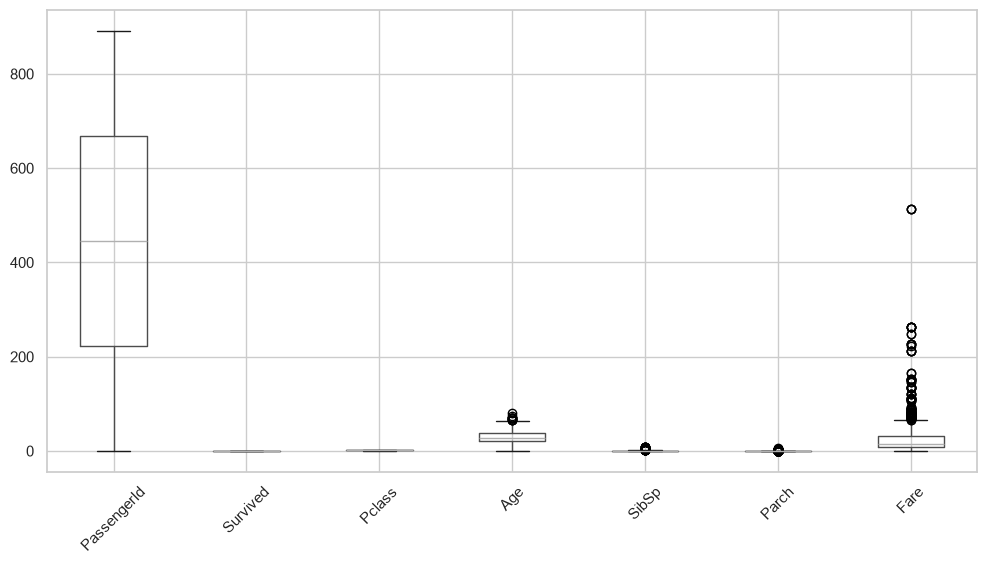

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

titanic = pd.read_csv("../Session-03/titanic (1).csv")
# Shape
print("Shape:", titanic.shape)
# Dataset Info
titanic.info()
# Missing Values
missing = pd.DataFrame({
    "Missing Count": titanic.isnull().sum(),
    "Missing Percentage": round((titanic.isnull().sum()/len(titanic))*100,2)
})

missing
# Duplicates
print("Duplicate Rows:", titanic.duplicated().sum())
# Data Types
print(titanic.dtypes)
# Invalid Values
print("Negative Age:", (titanic["Age"]<0).sum())
print("Negative Fare:", (titanic["Fare"]<0).sum())
print("Invalid Survived:", (~titanic["Survived"].isin([0,1])).sum())
print("Invalid Pclass:", (~titanic["Pclass"].isin([1,2,3])).sum())

# Category Consistency
print(titanic["Sex"].value_counts(dropna=False))
print(titanic["Embarked"].value_counts(dropna=False))
print(titanic["Pclass"].value_counts(dropna=False))
# Summary Statistics
titanic.describe(include="all")
# Outliers
numeric_cols=titanic.select_dtypes(include=np.number).columns

plt.figure(figsize=(12,6))
titanic[numeric_cols].boxplot()
plt.xticks(rotation=45)
plt.show()


### Step 2 — Clean the Dataset
Handle missing values (with justification), duplicates, incorrect types, inconsistent values, and
invalid values. Decide on an outlier strategy (remove / keep / cap) and justify it.

In [28]:
# Step 2: Clean the Dataset

# Fill missing Age values
titanic["Age"] = titanic["Age"].fillna(titanic["Age"].median())

# Fill missing Embarked values
titanic["Embarked"] = titanic["Embarked"].fillna(titanic["Embarked"].mode()[0])

# Drop Cabin column
titanic.drop(columns="Cabin", errors="ignore", inplace=True)

# Remove duplicate rows
titanic.drop_duplicates(inplace=True)

# Check missing values
print(titanic.isnull().sum())

# Handle outliers in Fare using IQR Capping
Q1 = titanic["Fare"].quantile(0.25)
Q3 = titanic["Fare"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

titanic["Fare"] = titanic["Fare"].clip(lower, upper)

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


### Step 3 — Prepare Features
Encode at least 2 categorical columns (choosing an appropriate method for each) and scale at
least 1 numerical column (choosing an appropriate scaler given what you know about its
distribution).

In [ ]:
from sklearn.preprocessing import LabelEncoder, RobustScaler

# Encode Sex
if titanic["Sex"].dtype == "object":
    le = LabelEncoder()
    titanic["Sex"] = le.fit_transform(titanic["Sex"])

# Encode Embarked only if it still exists
if "Embarked" in titanic.columns:
    titanic = pd.get_dummies(
        titanic,
        columns=["Embarked"],
        drop_first=True
    )

# Scale Fare
scaler = RobustScaler()
titanic["Fare"] = scaler.fit_transform(titanic[["Fare"]])

print(titanic.head())


   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name  Sex   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris    1  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...    0  38.0      1      0   
2                             Heikkinen, Miss. Laina    0  26.0      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)    0  35.0      1      0   
4                           Allen, Mr. William Henry    1  35.0      0      0   

             Ticket      Fare  Embarked_Q  Embarked_S  
0         A/5 21171 -0.312011       False        True  
1          PC 17599  2.216591       False       False  
2  STON/O2. 3101282 -0.282777       False        True  
3            113803  1.673732       False        True  
4            373

In [33]:
print(titanic.columns.tolist())

['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked_Q', 'Embarked_S']


### Step 4 — Perform EDA
At least one univariate chart, one bivariate chart, and the correlation heatmap. Interpret each
one in a sentence or two.

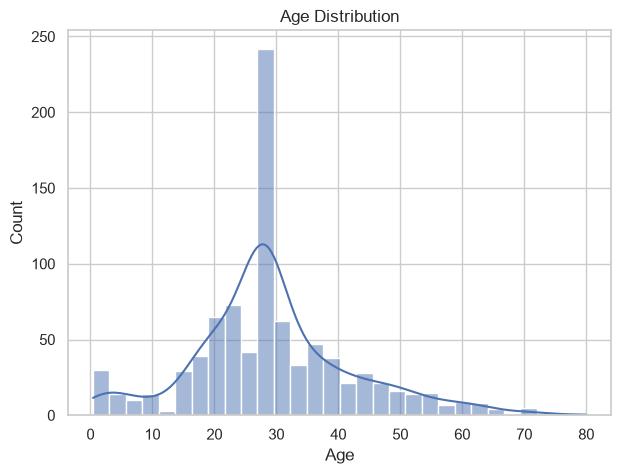

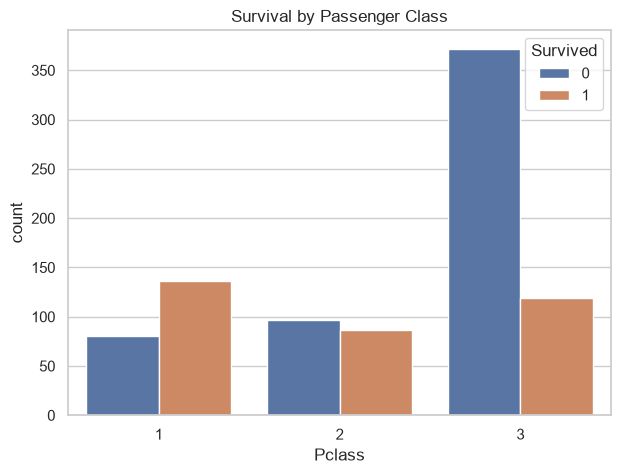

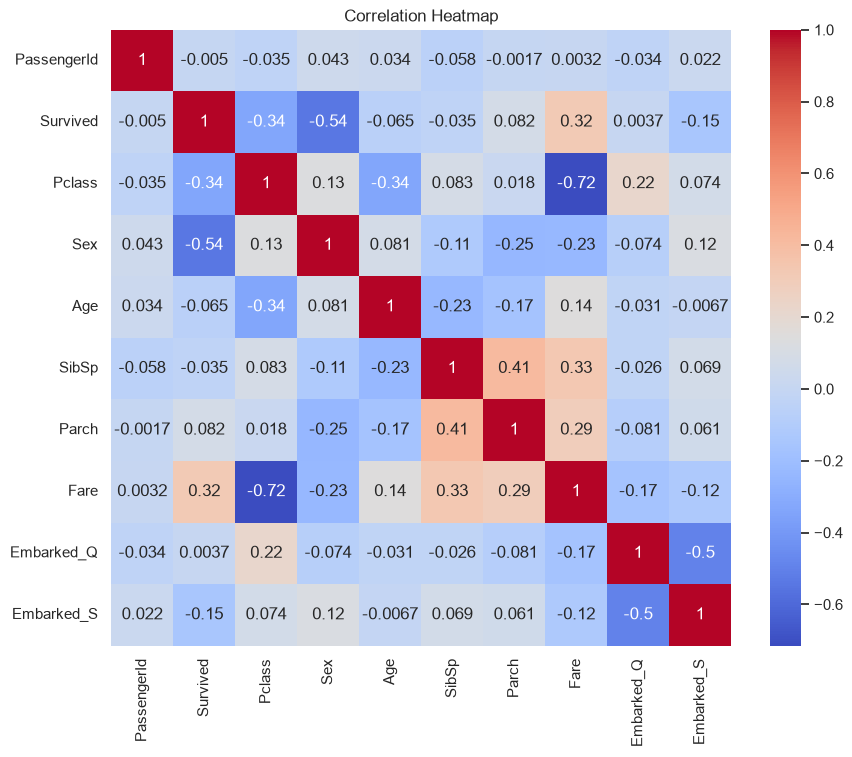

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))

sns.histplot(titanic["Age"], bins=30, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()
plt.figure(figsize=(7,5))

sns.countplot(
    data=titanic,
    x="Pclass",
    hue="Survived"
)

plt.title("Survival by Passenger Class")

plt.show()

plt.figure(figsize=(10,8))

sns.heatmap(
    titanic.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

### Step 5 — Engineer New Features
Build at least 3 new features (you can reuse ideas from Section 6, or invent your own from the
Challenge Question).

In [ ]:
# Family Size
titanic["FamilySize"] = titanic["SibSp"] + titanic["Parch"] + 1

# Is Alone
titanic["IsAlone"] = (titanic["FamilySize"] == 1).astype(int)

# Age Group
def bucket_age(age):

    if age < 13:
        return "Child"

    elif age < 20:
        return "Teen"

    elif age < 60:
        return "Adult"

    else:
        return "Senior"

titanic["AgeGroup"] = titanic["Age"].apply(bucket_age)

titanic[["Age","FamilySize","IsAlone","AgeGroup"]].head()

,Name,FamilySize,IsAlone,AgeGroup,Title,TicketLength
0,"Braund, Mr. Owen Harris",2,0,Young Adult,Mr,9
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",2,0,Adult,Mrs,8
2,"Heikkinen, Miss. Laina",1,1,Young Adult,Miss,16
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",2,0,Young Adult,Mrs,6
4,"Allen, Mr. William Henry",1,1,Young Adult,Mr,6


### Step 6 — Reflection Questions

Answer each in a sentence or two:

1. Which single preprocessing step (from Steps 1-3) had the biggest impact on the data, in your
   judgment? What would have gone wrong downstream if you'd skipped it?
2. Which visualization from Step 4 was the most informative — the one you'd actually show a
   stakeholder? Why that one specifically?
3. Which engineered feature from Step 5 do you expect to be most useful for predicting survival,
   and why?
4. If the next step were training a machine learning model, what's the **one thing** you'd want
   to double-check or do differently before starting?

**Your answers:**

1.

2.

3.

4.

---
## Wrap-up

Today you moved from "I can describe data" to "I can prepare *any* dataset, defensibly, from raw
export to model-ready" — on both a deliberately messy teaching dataset and the real Titanic data:
- Systematically assessed data quality before trusting anything
- Cleaned missing values, duplicates, wrong types, inconsistent categories, and invalid values —
  each with reasoning, not a fixed recipe
- Detected outliers and weighed remove vs. keep vs. cap
- Encoded categorical features (Label, Ordinal, One-Hot, and the concepts behind Frequency,
  Binary, and Target encoding)
- Scaled numerical features (Min-Max, Standard, Robust) and saw how outliers affect each
  differently
- Ran full univariate, bivariate, and correlation-based EDA, with interpretation at every step
- Engineered `FamilySize`, `IsAlone`, `Title`, `AgeGroup`, `FareCategory`, and more
- Practiced the entire pipeline independently, end to end

**Next time:** we start actually training machine learning models — on data you now know how to
properly prepare for that step.

---
### 🔎 One Last Reflection

Before you close this notebook, answer one more question in your own words:

> *If you had more time before building a Machine Learning model, what additional preprocessing
> or feature engineering would you perform, and why?*

**Your answer:**

